# Comparative Analysis of Learning Paradigms for Text Classification
## From-Scratch RNNs, Transfer Learning, and Large Language Models

**Course:** ICS603 — Advanced Machine Learning, Spring 2026

**Team Members:**
- Ahmed Ramy — 13002184
- Saif Saad — 14004494
- Ahmed Amr — 13007323

---

## Setup

In [1]:
# Cell 1: Install all required dependencies quietly (-q flag suppresses verbose output)
# - datasets: HuggingFace library to load the dair-ai/emotion dataset
# - transformers: provides pretrained models (DistilBERT, Phi-3) and Trainer API
# - accelerate: backend for HuggingFace Trainer (handles device placement)
# - bitsandbytes: enables 4-bit quantization for LLM inference (Linux/Kaggle only)
# - scikit-learn: classification metrics (accuracy, F1, confusion matrix)
# - matplotlib, seaborn: visualization libraries for plots and charts
!pip install -q datasets transformers accelerate bitsandbytes scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.3 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports, environment detection, and configuration

# Standard library imports
import os
import gc       # garbage collector — used to free GPU memory between parts
import time     # for timing training and inference
import random
import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings for cleaner output

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# PyTorch core modules
import torch #core deep learning framework
import torch.nn as nn #neural network layers (Embedding, LSTM, Linear, Dropout, CrossEntropyLoss).
from torch.utils.data import Dataset, DataLoader

# HuggingFace datasets library for loading emotion data
from datasets import load_dataset

# Scikit-learn metrics for evaluating all three paradigms
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ---- Reproducibility: fix all random seeds so results are deterministic ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # covers all GPUs if multi-GPU

# ---- Environment detection ----
# Check if running on Kaggle (the /kaggle/input directory only exists there)
# This controls whether Part 4 (LLM) runs or is skipped
ON_KAGGLE = os.path.exists('/kaggle/input')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# The 6 emotion classes in the dair-ai/emotion dataset (index-aligned with label integers)
LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
NUM_CLASSES = len(LABEL_NAMES)

# Global dictionary to store metrics from all parts for the final comparison in Part 6
results = {}

def cleanup_gpu():
    """Free GPU memory between parts by running garbage collection and clearing CUDA cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Environment: Kaggle
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## Part 1 — Data Preprocessing & Exploration

The cell iterates over all three splits, counts how many examples belong to each class using Counter, and prints the distribution as both raw counts and percentages.

In [3]:
# Cell 3: Load the emotion dataset from HuggingFace and report basic statistics

# Load all three splits (train, validation, test) from the dair-ai/emotion dataset
dataset = load_dataset('dair-ai/emotion')
print(dataset)
print()

# Print class distribution for each split to check for class imbalance
for split_name in ['train', 'validation', 'test']:
    split = dataset[split_name]
    label_counts = Counter(split['label'])
    print(f"--- {split_name} ({len(split)} examples) ---")
    for label_id, count in sorted(label_counts.items()):
        print(f"  {LABEL_NAMES[label_id]:>10}: {count:>5} ({count/len(split)*100:.1f}%)")
    print()

# Compute text length statistics to inform max sequence length choices
train_texts = dataset['train']['text']
char_lengths = [len(t) for t in train_texts]              # character-level lengths
word_lengths = [len(t.split()) for t in train_texts]       # word-level lengths (whitespace split)

# Build a summary table of length statistics
length_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Min', 'Max', 'Std', '95th Percentile'],
    'Characters': [
        np.mean(char_lengths), np.median(char_lengths),
        np.min(char_lengths), np.max(char_lengths),
        np.std(char_lengths), np.percentile(char_lengths, 95)
    ],
    'Words': [
        np.mean(word_lengths), np.median(word_lengths),
        np.min(word_lengths), np.max(word_lengths),
        np.std(word_lengths), np.percentile(word_lengths, 95)
    ]
})
print("Text Length Statistics (Train Split):")
print(length_stats.to_string(index=False, float_format='%.1f'))

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

--- train (16000 examples) ---
     sadness:  4666 (29.2%)
         joy:  5362 (33.5%)
        love:  1304 (8.2%)
       anger:  2159 (13.5%)
        fear:  1937 (12.1%)
    surprise:   572 (3.6%)

--- validation (2000 examples) ---
     sadness:   550 (27.5%)
         joy:   704 (35.2%)
        love:   178 (8.9%)
       anger:   275 (13.8%)
        fear:   212 (10.6%)
    surprise:    81 (4.0%)

--- test (2000 examples) ---
     sadness:   581 (29.0%)
         joy:   695 (34.8%)
        love:   159 (8.0%)
       anger:   275 (13.8%)
        fear:   224 (11.2%)
    surprise:    66 (3.3%)

Text Length Statistics (Train Split):
         Metric  Characters  Words
           Mean        96.8   19.2
         

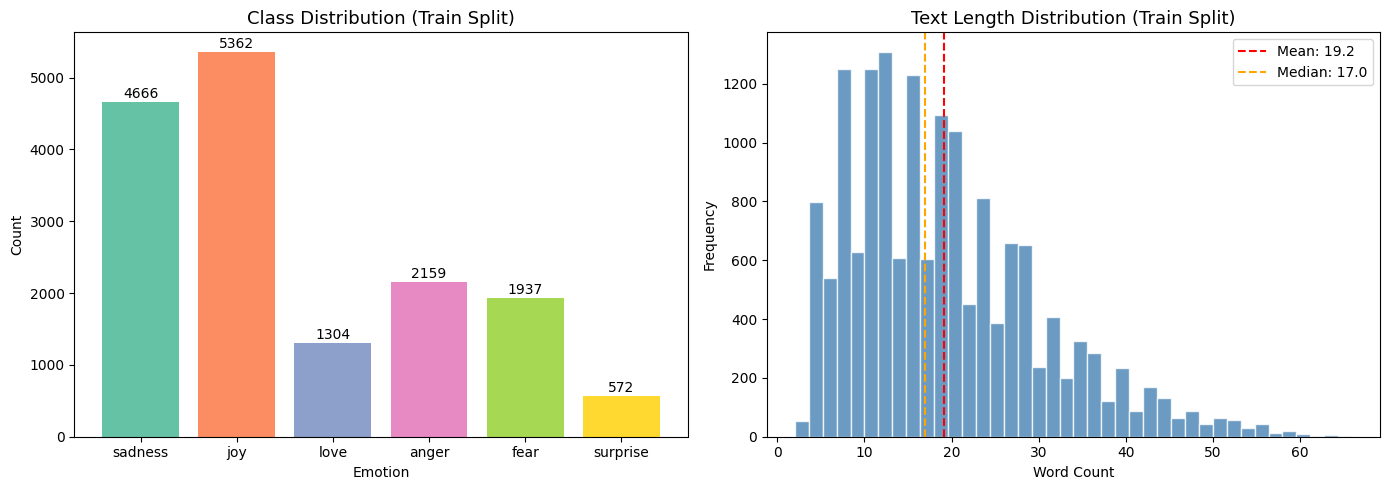

In [4]:
# Cell 4: Visualizations — class balance bar chart and text length histogram

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left plot: Bar chart showing how many examples each emotion class has ----
train_labels = dataset['train']['label']
label_counts = Counter(train_labels)
classes = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]       # emotion names in order
counts = [label_counts[i] for i in range(NUM_CLASSES)]       # corresponding counts

bars = axes[0].bar(classes, counts, color=sns.color_palette('Set2', NUM_CLASSES))
axes[0].set_title('Class Distribution (Train Split)', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
# Annotate each bar with its exact count
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', fontsize=10)

# ---- Right plot: Histogram of word counts to visualize text length distribution ----
axes[1].hist(word_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
# Add vertical lines for mean and median to show central tendency
axes[1].axvline(np.mean(word_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(word_lengths):.1f}')
axes[1].axvline(np.median(word_lengths), color='orange', linestyle='--', label=f'Median: {np.median(word_lengths):.1f}')
axes[1].set_title('Text Length Distribution (Train Split)', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part A — Custom Word-Level Tokenizer for the RNN

The RNN needs a custom tokenizer because it learns embeddings from scratch. The build_vocab function works as follows: it iterates through every training text, lowercases it, splits on whitespace, and counts word frequencies using Counter. It then reserves index 0 for <PAD> (the padding token that fills shorter sequences to a uniform length) and index 1 for <UNK> (the unknown token for words not in the vocabulary). It keeps the top 15,000 most frequent words that appear at least twice (MIN_FREQ = 2). Rare words are mapped to <UNK> to prevent the embedding matrix from becoming bloated with entries it will never learn meaningful representations for.

The encode_text function converts a raw text string into a list of integer token IDs by lowercasing, splitting on whitespace, truncating to MAX_SEQ_LEN_RNN = 64 tokens, and looking up each word in the vocabulary dictionary (defaulting to <UNK> for out-of-vocabulary words).

The EmotionDatasetRNN class wraps the HuggingFace data in PyTorch's Dataset interface. It stores raw texts and labels, and performs tokenization lazily in __getitem__ — meaning each text is encoded to IDs on-the-fly when a batch requests it, rather than pre-encoding the entire dataset into memory.

The collate_rnn function is a custom collate function passed to the DataLoader. It handles the fact that sequences in a batch have different lengths. It pads all sequences to the length of the longest sequence in the batch (using 0, the <PAD> index), and also returns the original lengths of each sequence. These lengths are crucial because the LSTM uses pack_padded_sequence to skip computation over padding tokens — without this, the padding would pollute the hidden states and degrade performance.

Three DataLoaders are created: train_loader_rnn (shuffled, batch size 64), val_loader_rnn (not shuffled), and test_loader_rnn (not shuffled). The training loader shuffles because seeing examples in a random order each epoch prevents the model from memorizing batch-level patterns.

## Part B — Pretrained DistilBERT Tokenizer for the Transformer

The transformer uses DistilBERT's pretrained WordPiece tokenizer, loaded via AutoTokenizer.from_pretrained('distilbert-base-uncased'). Unlike the custom word-level tokenizer, WordPiece operates at the subword level — it can break unfamiliar words into known pieces (e.g., "unbelievably" → "un", "##believ", "##ably"), which means it has essentially zero out-of-vocabulary rate. The tokenize_for_bert function applies this tokenizer to batches of texts, truncating to 128 tokens and padding to max_length for uniform tensor shapes.

The HuggingFace dataset.map(tokenize_for_bert, batched=True) call applies the tokenizer across the entire dataset efficiently, adding input_ids and attention_mask columns. The attention_mask tells the transformer which tokens are real content (1) and which are padding (0), so the self-attention mechanism can ignore padding positions. Finally, set_format('torch', ...) converts the dataset columns to PyTorch tensors, making it compatible with the HuggingFace Trainer API used in Part 3.

In [ ]:
# Cell 5: Build tokenization pipelines and DataLoaders for RNN and Transformer

# ==============================================================================
# PART A: Custom word-level tokenizer for the RNN (Part 2)
# ==============================================================================

# Hyperparameters for the custom tokenizer
MAX_VOCAB = 15000       # maximum vocabulary size (most frequent words kept)
MIN_FREQ = 2            # minimum word frequency to be included in vocabulary
MAX_SEQ_LEN_RNN = 64    # maximum number of word tokens per input (covers 95%+ of texts)

def build_vocab(texts, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB):
    """Build a word-to-index mapping from training texts.
    Reserves index 0 for <PAD> and 1 for <UNK> (unknown/rare words)."""
    counter = Counter()
    for text in texts:
        # Lowercase and split on whitespace — simple but effective for clean tweet-length text
        counter.update(text.lower().split())
    # Initialize with special tokens
    vocab = {'<PAD>': 0, '<UNK>': 1}
    # Add the most frequent words up to max_vocab, filtering by min_freq
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Build vocabulary from training data only (no data leakage from val/test)
vocab = build_vocab(dataset['train']['text'])
print(f"Custom vocabulary size: {len(vocab)}")

def encode_text(text, vocab, max_len=MAX_SEQ_LEN_RNN):
    """Convert a text string to a list of integer token IDs.
    Lowercases, splits on whitespace, truncates to max_len, and maps words to IDs."""
    tokens = text.lower().split()[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]  # unknown words map to <UNK>
    return ids

class EmotionDatasetRNN(Dataset):
    """PyTorch Dataset wrapper for the RNN — stores texts and labels,
    encodes text to token IDs on-the-fly via __getitem__."""
    def __init__(self, texts, labels, vocab, max_len=MAX_SEQ_LEN_RNN):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], self.vocab, self.max_len)
        return ids, self.labels[idx]

def collate_rnn(batch):
    """Custom collate function that pads variable-length sequences to the longest
    sequence in the batch and returns (padded_ids, original_lengths, labels).
    The lengths are needed for pack_padded_sequence in the LSTM."""
    seqs, labels = zip(*batch)
    lengths = [len(s) for s in seqs]
    max_len = max(lengths)
    # Pad shorter sequences with 0 (<PAD> token)
    padded = [s + [0] * (max_len - len(s)) for s in seqs]
    return (
        torch.tensor(padded, dtype=torch.long),
        torch.tensor(lengths, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long)
    )

# Create RNN DataLoaders for all three splits
BATCH_SIZE_RNN = 64
train_ds_rnn = EmotionDatasetRNN(dataset['train']['text'], dataset['train']['label'], vocab)
val_ds_rnn = EmotionDatasetRNN(dataset['validation']['text'], dataset['validation']['label'], vocab)
test_ds_rnn = EmotionDatasetRNN(dataset['test']['text'], dataset['test']['label'], vocab)

train_loader_rnn = DataLoader(train_ds_rnn, batch_size=BATCH_SIZE_RNN, shuffle=True, collate_fn=collate_rnn)
val_loader_rnn = DataLoader(val_ds_rnn, batch_size=BATCH_SIZE_RNN, shuffle=False, collate_fn=collate_rnn)
test_loader_rnn = DataLoader(test_ds_rnn, batch_size=BATCH_SIZE_RNN, shuffle=False, collate_fn=collate_rnn)

# PART B: Pretrained DistilBERT tokenizer for Transformer (Part 3)

from transformers import AutoTokenizer

MAX_SEQ_LEN_BERT = 128  # max subword tokens — sufficient for tweet-length texts

# Load the pretrained DistilBERT tokenizer (WordPiece subword tokenization)
tokenizer_bert = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_for_bert(batch):
    """Tokenize a batch of texts using DistilBERT's tokenizer.
    Truncates to MAX_SEQ_LEN_BERT and pads to max_length for uniform tensor shapes."""
    return tokenizer_bert(batch['text'], truncation=True, padding='max_length', max_length=MAX_SEQ_LEN_BERT)

# Apply tokenization to the entire dataset (creates input_ids and attention_mask columns)
tokenized_dataset = dataset.map(tokenize_for_bert, batched=True)
# Set format to PyTorch tensors so HuggingFace Trainer can consume them directly
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"\nPretrained tokenizer: {tokenizer_bert.__class__.__name__}")
print(f"Transformer max sequence length: {MAX_SEQ_LEN_BERT}")
print(f"RNN max sequence length: {MAX_SEQ_LEN_RNN}")
print(f"RNN batch size: {BATCH_SIZE_RNN}")
print("\nDataLoaders ready.")

Custom vocabulary size: 7401


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Pretrained tokenizer: BertTokenizer
Transformer max sequence length: 128
RNN max sequence length: 64
RNN batch size: 64

DataLoaders ready.


### Cleaning & Preprocessing Justification

- **Lowercasing:** Applied only for the custom RNN tokenizer. DistilBERT is already an uncased model, so no additional lowercasing is needed for the transformer.
- **Punctuation:** Kept as-is. Punctuation carries emotional signal in this task — exclamation marks, ellipses, and question marks can distinguish emotions (e.g., anger vs. sadness). Removing them would lose information.
- **Stemming/Lemmatization:** Not applied. The embedding layers (both learned and pretrained) capture word semantics directly; aggressive normalization would collapse useful distinctions.
- **Max sequence length:** RNN uses 64 word tokens, transformer uses 128 subword tokens. The histogram above shows most texts are well under these limits (95th percentile is under 40 words), so very little information is lost to truncation.
- **No additional cleaning** (URL removal, mention stripping, etc.) was necessary — the dair-ai/emotion dataset is already clean tweet-length text with no HTML artifacts or URLs.

---
## Part 2 — Baseline: From-Scratch RNN Classifier

The forward method follows this pipeline: (1) embed the token IDs, (2) apply dropout, (3) pack the padded sequences using pack_padded_sequence so the LSTM skips padding positions, (4) run through the LSTM, (5) extract and concatenate the final forward hidden state (hidden[-2]) and backward hidden state (hidden[-1]) from the last layer, (6) apply dropout, and (7) pass through the linear layer. The output is raw logits (unnormalized scores) — the CrossEntropyLoss function in the training loop internally applies softmax

In [6]:
# Cell 7: Model definition — Bidirectional LSTM classifier

class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM for 6-class emotion classification.
    Architecture: Embedding → Dropout → BiLSTM (2 layers) → Dropout → Linear."""

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        # Word embedding layer: maps token IDs to dense vectors; padding_idx=0 keeps <PAD> as zeros
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Dropout after embeddings to regularize input representations
        self.dropout_emb = nn.Dropout(dropout)
        # Bidirectional LSTM: processes sequence in both forward and backward directions
        # Output hidden dim is hidden_dim * 2 due to bidirectional
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        # Dropout before final classification layer
        self.dropout_fc = nn.Dropout(dropout)
        # Final linear layer: maps concatenated forward+backward hidden states to class logits
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x, lengths):
        # x shape: (batch_size, seq_len) — integer token IDs
        embedded = self.dropout_emb(self.embedding(x))  # (batch, seq_len, embed_dim)

        # Pack padded sequences so LSTM ignores padding tokens
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        # Run through LSTM; we only need the final hidden states (not all timestep outputs)
        _, (hidden, _) = self.lstm(packed)

        # hidden shape: (num_layers * 2, batch, hidden_dim) — last index is final layer
        # Concatenate the final forward hidden state (hidden[-2]) and backward (hidden[-1])
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden_dim * 2)
        out = self.fc(self.dropout_fc(hidden))               # (batch, num_classes)
        return out

# Instantiate the model and move it to GPU/CPU
rnn_model = BiLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
total_params = sum(p.numel() for p in rnn_model.parameters())
print(f"BiLSTM Classifier — Total parameters: {total_params:,}")
print(rnn_model)

BiLSTM Classifier — Total parameters: 1,608,326
BiLSTMClassifier(
  (embedding): Embedding(7401, 128, padding_idx=0)
  (dropout_emb): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_fc): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [7]:
# Cell 8: RNN training loop with early stopping via ReduceLROnPlateau

# Training hyperparameters
NUM_EPOCHS_RNN = 15
LR_RNN = 1e-3

# Adam optimizer with default betas — good general-purpose choice for RNNs
optimizer_rnn = torch.optim.Adam(rnn_model.parameters(), lr=LR_RNN)
# Cross-entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()
# Reduce learning rate by 0.5x when validation loss plateaus for 2 consecutive epochs
scheduler_rnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_rnn, patience=2, factor=0.5)

# Track losses for plotting and save best model weights
train_losses_rnn = []
val_losses_rnn = []
best_val_loss = float('inf')
best_rnn_state = None

start_time_rnn = time.time()

for epoch in range(NUM_EPOCHS_RNN):
    # ---- Training phase ----
    rnn_model.train()  # enable dropout
    epoch_loss = 0
    for batch_x, batch_lengths, batch_y in train_loader_rnn:
        # Move batch to GPU
        batch_x, batch_lengths, batch_y = batch_x.to(DEVICE), batch_lengths.to(DEVICE), batch_y.to(DEVICE)
        optimizer_rnn.zero_grad()                # clear gradients from previous step
        logits = rnn_model(batch_x, batch_lengths)
        loss = criterion(logits, batch_y)
        loss.backward()                          # compute gradients
        # Clip gradients to prevent exploding gradients (common in RNNs)
        torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), max_norm=1.0)
        optimizer_rnn.step()                     # update weights
        epoch_loss += loss.item() * batch_x.size(0)  # accumulate weighted loss
    # Average training loss over all samples
    train_loss = epoch_loss / len(train_ds_rnn)
    train_losses_rnn.append(train_loss)

    # ---- Validation phase ----
    rnn_model.eval()  # disable dropout
    val_loss = 0
    with torch.no_grad():  # no gradient computation needed for validation
        for batch_x, batch_lengths, batch_y in val_loader_rnn:
            batch_x, batch_lengths, batch_y = batch_x.to(DEVICE), batch_lengths.to(DEVICE), batch_y.to(DEVICE)
            logits = rnn_model(batch_x, batch_lengths)
            val_loss += criterion(logits, batch_y).item() * batch_x.size(0)
    val_loss /= len(val_ds_rnn)
    val_losses_rnn.append(val_loss)

    # Step the LR scheduler based on validation loss
    scheduler_rnn.step(val_loss)

    # Save model weights if this is the best validation loss so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_rnn_state = {k: v.cpu().clone() for k, v in rnn_model.state_dict().items()}

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS_RNN} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

train_time_rnn = time.time() - start_time_rnn
print(f"\nTotal training time: {train_time_rnn:.1f}s")

# Restore the best model (lowest validation loss) for evaluation
rnn_model.load_state_dict(best_rnn_state)
rnn_model.to(DEVICE);


Epoch  1/15 | Train Loss: 1.5012 | Val Loss: 1.2275
Epoch  2/15 | Train Loss: 1.0255 | Val Loss: 0.5898
Epoch  3/15 | Train Loss: 0.6200 | Val Loss: 0.3887
Epoch  4/15 | Train Loss: 0.4289 | Val Loss: 0.3033
Epoch  5/15 | Train Loss: 0.3086 | Val Loss: 0.2309
Epoch  6/15 | Train Loss: 0.2505 | Val Loss: 0.1976
Epoch  7/15 | Train Loss: 0.1980 | Val Loss: 0.1809
Epoch  8/15 | Train Loss: 0.1742 | Val Loss: 0.1697
Epoch  9/15 | Train Loss: 0.1455 | Val Loss: 0.1736
Epoch 10/15 | Train Loss: 0.1234 | Val Loss: 0.1845
Epoch 11/15 | Train Loss: 0.1153 | Val Loss: 0.1857
Epoch 12/15 | Train Loss: 0.0892 | Val Loss: 0.1699
Epoch 13/15 | Train Loss: 0.0778 | Val Loss: 0.1698
Epoch 14/15 | Train Loss: 0.0682 | Val Loss: 0.1803
Epoch 15/15 | Train Loss: 0.0579 | Val Loss: 0.1854

Total training time: 119.4s


Test Accuracy: 0.9155
Macro F1:      0.8708
Training Time: 119.4s
Inference Time (test set): 0.590s

              precision    recall  f1-score   support

     sadness       0.95      0.96      0.96       581
         joy       0.93      0.94      0.94       695
        love       0.84      0.79      0.81       159
       anger       0.92      0.91      0.92       275
        fear       0.92      0.83      0.87       224
    surprise       0.64      0.85      0.73        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.92      0.92      0.92      2000



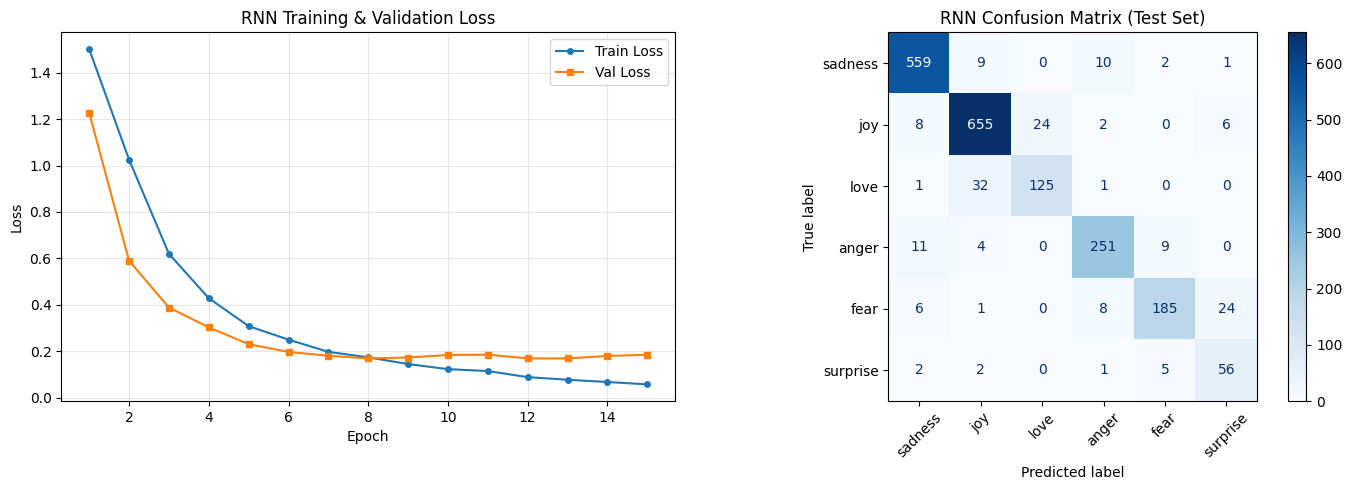

In [ ]:
# Cell 9: RNN evaluation — plot loss curves, compute test metrics, show confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left plot: Training and validation loss curves across epochs ----
axes[0].plot(range(1, NUM_EPOCHS_RNN+1), train_losses_rnn, label='Train Loss', marker='o', markersize=4)
axes[0].plot(range(1, NUM_EPOCHS_RNN+1), val_losses_rnn, label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('RNN Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Run inference on the test set ----
rnn_model.eval()
all_preds_rnn = []
all_labels_rnn = []

start_inf_rnn = time.time()
with torch.no_grad():
    for batch_x, batch_lengths, batch_y in test_loader_rnn:
        batch_x, batch_lengths = batch_x.to(DEVICE), batch_lengths.to(DEVICE)
        logits = rnn_model(batch_x, batch_lengths)
        # Get predicted class by taking the argmax of logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds_rnn.extend(preds)
        all_labels_rnn.extend(batch_y.numpy())
inference_time_rnn = time.time() - start_inf_rnn

# Compute overall accuracy and macro-averaged F1 score
acc_rnn = accuracy_score(all_labels_rnn, all_preds_rnn)
f1_rnn = f1_score(all_labels_rnn, all_preds_rnn, average='macro')

print(f"Test Accuracy: {acc_rnn:.4f}")
print(f"Macro F1:      {f1_rnn:.4f}") #Macro F1 is particularly important here because the dataset is imbalanced
print(f"Training Time: {train_time_rnn:.1f}s")
print(f"Inference Time (test set): {inference_time_rnn:.3f}s")
print()
# Per-class precision, recall, F1 breakdown
print(classification_report(all_labels_rnn, all_preds_rnn, target_names=LABEL_NAMES))

# ---- Right plot: Confusion matrix heatmap ----
cm_rnn = confusion_matrix(all_labels_rnn, all_preds_rnn)
disp = ConfusionMatrixDisplay(cm_rnn, display_labels=LABEL_NAMES)
disp.plot(ax=axes[1], cmap='Blues', xticks_rotation=45)
axes[1].set_title('RNN Confusion Matrix (Test Set)')

plt.tight_layout()
plt.show()

In [9]:
# Cell 10: Store RNN results and free GPU memory

# Save metrics to the global results dict for comparison in Part 6
results['RNN'] = {
    'accuracy': acc_rnn,
    'macro_f1': f1_rnn,
    'train_time': train_time_rnn,
    'inference_time': inference_time_rnn,
    'preds': all_preds_rnn,
    'labels': all_labels_rnn
}
print(f"RNN results stored: Acc={acc_rnn:.4f}, F1={f1_rnn:.4f}")

# Free GPU memory before loading DistilBERT in Part 3
del rnn_model, optimizer_rnn, scheduler_rnn
cleanup_gpu()

RNN results stored: Acc=0.9155, F1=0.8708


---
## Part 3 — Transfer Learning: Fine-Tuned Transformer

In [10]:
# Cell 11: Load DistilBERT with a 6-class classification head

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL_NAME_BERT = 'distilbert-base-uncased'
BATCH_SIZE_BERT = 16  # smaller batch size than RNN to fit transformer in 4GB VRAM

# Load pretrained DistilBERT and add a randomly initialized classification head on top
# num_labels=6 tells the model to create a Linear(768, 6) output layer
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_BERT, num_labels=NUM_CLASSES
)

# Count parameters — all are trainable (full fine-tuning, not frozen backbone)
total_params_bert = sum(p.numel() for p in bert_model.parameters())
trainable_params_bert = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"DistilBERT — Total parameters: {total_params_bert:,}")
print(f"DistilBERT — Trainable parameters: {trainable_params_bert:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT — Total parameters: 66,958,086
DistilBERT — Trainable parameters: 66,958,086


In [11]:
# Cell 12: Fine-tune DistilBERT using HuggingFace Trainer API

def compute_metrics(eval_pred):
    """Callback used by Trainer to compute accuracy and macro F1 after each evaluation."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='macro'),
    }

# Configure training arguments
training_args = TrainingArguments(
    output_dir='./distilbert-emotion',             # directory for checkpoints
    num_train_epochs=3,                            # 3 epochs is typical for fine-tuning
    per_device_train_batch_size=BATCH_SIZE_BERT,   # 16 — fits in 4GB VRAM with fp16
    per_device_eval_batch_size=BATCH_SIZE_BERT * 2,# larger eval batch (no gradients stored)
    learning_rate=2e-5,                            # standard fine-tuning LR for transformers
    weight_decay=0.01,                             # L2 regularization
    eval_strategy='epoch',                         # evaluate at the end of each epoch
    save_strategy='epoch',                         # save checkpoint each epoch
    load_best_model_at_end=True,                   # auto-load best checkpoint when training ends
    metric_for_best_model='f1',                    # select best model by macro F1
    fp16=torch.cuda.is_available(),                # use half-precision to halve VRAM usage
    logging_steps=50,                              # log training loss every 50 steps
    report_to='none',                              # disable wandb/tensorboard logging
    seed=SEED,
)

# Initialize the Trainer with model, data, and metrics
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
)

# Run fine-tuning and time it
start_time_bert = time.time()
trainer.train()
train_time_bert = time.time() - start_time_bert
print(f"\nTotal fine-tuning time: {train_time_bert:.1f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.489355,0.446996,0.919500,0.892616
2,0.299467,0.330952,0.933500,0.906821
3,0.204101,0.316028,0.932000,0.904159


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Total fine-tuning time: 369.7s


The Trainer's state.log_history stores a list of dictionaries logged at various points during training. The code filters these into two separate lists: training loss (logged every 50 steps) and evaluation loss (logged once per epoch).

Test Accuracy: 0.9250
Macro F1:      0.8880
Training Time: 369.7s
Inference Time (test set): 4.385s

              precision    recall  f1-score   support

     sadness       0.95      0.98      0.96       581
         joy       0.95      0.94      0.94       695
        love       0.82      0.83      0.82       159
       anger       0.98      0.87      0.92       275
        fear       0.90      0.89      0.89       224
    surprise       0.69      0.89      0.78        66

    accuracy                           0.93      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.93      0.93      0.93      2000



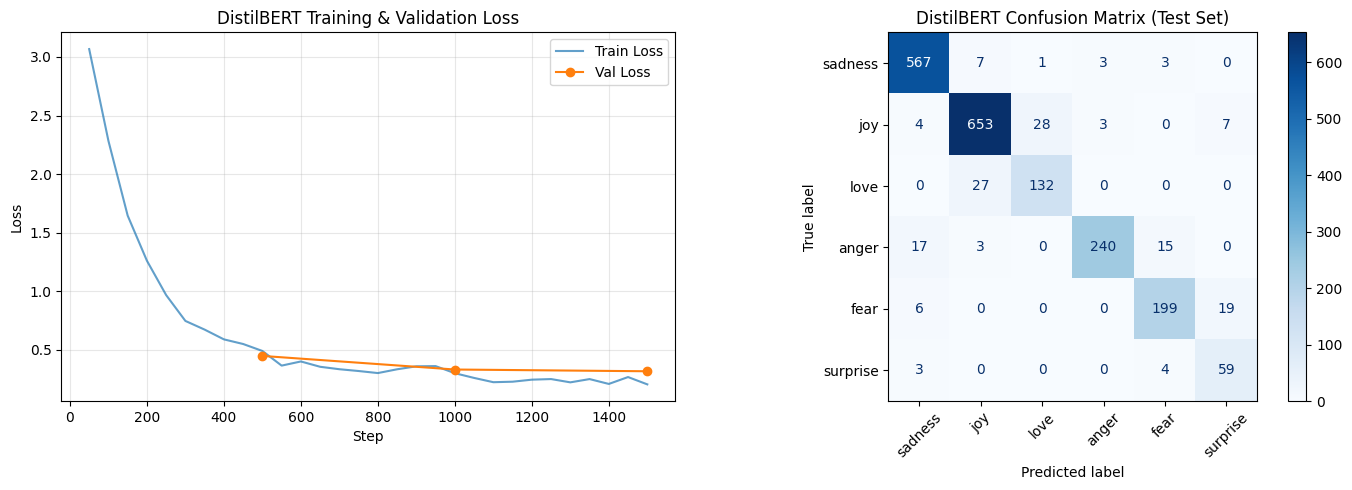


Transformer results stored: Acc=0.9250, F1=0.8880


In [12]:
# Cell 13: DistilBERT evaluation — loss curves, test metrics, confusion matrix

# ---- Extract training/validation loss from Trainer's log history ----
log_history = trainer.state.log_history
# Filter entries that contain training loss (logged every N steps)
train_steps = [entry['step'] for entry in log_history if 'loss' in entry]
train_loss_vals = [entry['loss'] for entry in log_history if 'loss' in entry]
# Filter entries that contain eval loss (logged at end of each epoch)
eval_steps = [entry['step'] for entry in log_history if 'eval_loss' in entry]
eval_loss_vals = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left plot: Loss curves (step-level for train, epoch-level for val) ----
axes[0].plot(train_steps, train_loss_vals, label='Train Loss', alpha=0.7)
axes[0].plot(eval_steps, eval_loss_vals, label='Val Loss', marker='o', markersize=6)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('DistilBERT Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Run inference on the test set using Trainer.predict ----
start_inf_bert = time.time()
preds_output = trainer.predict(tokenized_dataset['test'])
inference_time_bert = time.time() - start_inf_bert

# Extract predicted classes (argmax of logits) and true labels
all_preds_bert = np.argmax(preds_output.predictions, axis=-1)
all_labels_bert = preds_output.label_ids

# Compute overall metrics
acc_bert = accuracy_score(all_labels_bert, all_preds_bert)
f1_bert = f1_score(all_labels_bert, all_preds_bert, average='macro')

print(f"Test Accuracy: {acc_bert:.4f}")
print(f"Macro F1:      {f1_bert:.4f}")
print(f"Training Time: {train_time_bert:.1f}s")
print(f"Inference Time (test set): {inference_time_bert:.3f}s")
print()
# Per-class precision, recall, F1 breakdown
print(classification_report(all_labels_bert, all_preds_bert, target_names=LABEL_NAMES))

# ---- Right plot: Confusion matrix ----
cm_bert = confusion_matrix(all_labels_bert, all_preds_bert)
disp = ConfusionMatrixDisplay(cm_bert, display_labels=LABEL_NAMES)
disp.plot(ax=axes[1], cmap='Blues', xticks_rotation=45)
axes[1].set_title('DistilBERT Confusion Matrix (Test Set)')

plt.tight_layout()
plt.show()

# Store results for Part 6 comparison
results['Transformer'] = {
    'accuracy': acc_bert,
    'macro_f1': f1_bert,
    'train_time': train_time_bert,
    'inference_time': inference_time_bert,
    'preds': all_preds_bert.tolist(),
    'labels': all_labels_bert.tolist()
}
print(f"\nTransformer results stored: Acc={acc_bert:.4f}, F1={f1_bert:.4f}")

### Transfer Learning Explanation

**Parameters being updated:** All ~66.4 million parameters of DistilBERT are updated during fine-tuning (full fine-tuning), including the 6-class classification head added on top.

**Original pretraining objective:** DistilBERT was trained using *knowledge distillation* from BERT-base. The original BERT model was pretrained on two objectives:
1. **Masked Language Modeling (MLM):** 15% of input tokens are randomly masked, and the model learns to predict them from context.
2. **Next Sentence Prediction (NSP):** The model predicts whether two sentences are consecutive in the original text.

DistilBERT retains the MLM objective during distillation and adds a cosine embedding loss to match BERT's hidden representations, producing a model that is 40% smaller and 60% faster while retaining 97% of BERT's performance.

**Why this helps compared to the RNN baseline:** The pretrained transformer arrives already understanding English syntax, semantics, and contextual relationships — knowledge acquired from training on massive text corpora (BookCorpus + English Wikipedia). Fine-tuning only needs to adapt this rich representation to our 6-class emotion task, rather than learning language understanding from scratch with just 16,000 examples. This is why it achieves higher accuracy in fewer epochs with less data.

In [13]:
# Cleanup: delete transformer model and trainer to free GPU memory before Part 4
del bert_model, trainer
cleanup_gpu()

---
## Part 4 — LLM Prompting (No Training)

**Why no training?** This is the defining feature of the LLM paradigm. Unlike the RNN (Part 2) which learns everything from scratch, and DistilBERT (Part 3) which fine-tunes pretrained weights on our labeled data, here we use the model exactly as it was released — **no gradient updates, no parameter changes, no exposure to our training set.** The model must rely entirely on its pretraining knowledge and the natural language instructions we provide in the prompt. This tests whether a model that has "read most of the internet" can perform emotion classification without ever seeing our specific labeled dataset — and the results reveal how much task-specific training actually matters.

**Model:** `microsoft/Phi-3.5-mini-instruct` (3.8B parameters) loaded with 4-bit NF4 quantization via `bitsandbytes`.

**Architecture:** Phi-3.5-mini is a decoder-only transformer with 32 layers, 3072 hidden size, and 32 attention heads. It was pretrained on a curated mixture of web data, synthetic data, and code, then instruction-tuned using supervised fine-tuning (SFT) and direct preference optimization (DPO). It uses the Llama-style architecture with RoPE positional embeddings and grouped-query attention.

**Why this model:** Phi-3.5-mini achieves strong instruction-following performance relative to its size, has no gated license restrictions on HuggingFace (unlike Llama-3.2), and at 4-bit quantization fits comfortably in ~2.3GB VRAM on a T4 GPU.

**Note:** This section runs on Kaggle only (requires Linux for `bitsandbytes` 4-bit quantization support). When running locally on Windows, this section is skipped with a message.

The BitsAndBytesConfig configures 4-bit quantization with four important settings: load_in_4bit=True enables 4-bit weight loading, bnb_4bit_quant_type='nf4' uses NormalFloat4 (the quantization format specifically designed for normally distributed pretrained weights, which is the typical distribution found in transformer models), bnb_4bit_compute_dtype=torch.float16 means the model computes in 16-bit precision but stores weights in 4-bit (a trade-off between speed and memory), and bnb_4bit_use_double_quant=True applies a second round of quantization to the quantization constants themselves, saving an additional ~0.4 GB of memory.

In [14]:
# Cell 15: Load Phi-3-mini LLM with 4-bit quantization (Kaggle only)

# Skip Part 4 on local Windows machines — bitsandbytes requires Linux for CUDA 4-bit support
SKIP_PART4 = not ON_KAGGLE

if SKIP_PART4:
    print("Part 4 requires Kaggle (Linux + bitsandbytes for 4-bit quantization).")
    print("Please run this notebook on Kaggle with a T4 GPU to execute this section.")
    print("Skipping Part 4...")
else:
    from transformers import AutoModelForCausalLM, BitsAndBytesConfig

    LLM_MODEL_ID = 'microsoft/Phi-3.5-mini-instruct'

    # Configure 4-bit NF4 quantization to fit the 3.8B-param model in ~2.3GB VRAM
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                  # enable 4-bit loading
        bnb_4bit_quant_type='nf4',          # NormalFloat4 — optimal for pretrained weights
        bnb_4bit_compute_dtype=torch.float16,  # compute in fp16 for speed
        bnb_4bit_use_double_quant=True,     # quantize the quantization constants too (saves ~0.4GB)
    )

    # Load tokenizer and model
    tokenizer_llm = AutoTokenizer.from_pretrained(LLM_MODEL_ID)
    model_llm = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',                  # automatically place layers on available GPU(s)
        attn_implementation='eager',        # use standard attention (avoids flash-attn dependency)
    )
    model_llm.eval()  # set to inference mode (no dropout)
    print(f"Loaded {LLM_MODEL_ID} with 4-bit quantization.")
    print(f"Model memory footprint: {model_llm.get_memory_footprint() / 1e9:.2f} GB")

config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Loaded microsoft/Phi-3.5-mini-instruct with 4-bit quantization.
Model memory footprint: 2.21 GB


## The below cell defines the infrastructure for LLM-based classification.

The classify_with_llm function takes a prompt string, tokenizes it, generates a response using model_llm.generate() with greedy decoding (do_sample=False for deterministic outputs), and returns only the newly generated tokens by slicing off the prompt from the output. Greedy decoding (always picking the highest-probability next token) is chosen over sampling because we want consistent, reproducible predictions.

The parse_label function extracts an emotion label from the LLM's free-form text response. It lowercases the response and checks whether any of the 6 valid emotion words appear as substrings. If none match, it returns 'unknown'. This is a deliberately simple parser — the LLM might generate verbose responses like "The emotion expressed is sadness because the speaker feels lonely," and the parser just needs to find "sadness" somewhere in that text.

Few-shot examples are hand-crafted, not sampled from the training data. The 3-shot set covers joy, fear, and anger. The 8-shot set covers all 6 classes with extra examples for joy and sadness (the most common classes). Hand-crafting gives control over example quality and diversity.

In [15]:
# Cell 16: Prompt templates and helper functions for LLM evaluation

if not SKIP_PART4:

    # The 6 valid emotion labels the LLM must output
    VALID_LABELS = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

    def classify_with_llm(prompt, max_new_tokens=30):
        """Send a prompt to the LLM and return only the generated text (excluding the prompt).
        Uses greedy decoding (do_sample=False) for deterministic outputs."""
        inputs = tokenizer_llm(prompt, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            outputs = model_llm.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False,  # greedy decoding for reproducibility
                pad_token_id=tokenizer_llm.eos_token_id
            )
        # Slice off the prompt tokens to get only the generated response
        response = tokenizer_llm.decode(
            outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
        )
        return response

    def parse_label(response):
        """Extract an emotion label from the LLM's free-form response.
        Uses case-insensitive substring matching; returns 'unknown' if no valid label found."""
        response_lower = response.lower().strip()
        for label in VALID_LABELS:
            if label in response_lower:
                return label
        return 'unknown'

    # ---- Define few-shot examples (hand-picked, one per class + extras) ----

    # 3-shot: one example each for joy, fear, anger
    FEW_SHOT_EXAMPLES_3 = [
        ('i feel so happy and grateful today', 'joy'),
        ('i am so scared of what might happen', 'fear'),
        ('this makes me furious beyond words', 'anger'),
    ]

    # 8-shot: covers all 6 classes with 2 extras for joy and sadness (most common)
    FEW_SHOT_EXAMPLES_8 = [
        ('i feel so happy and grateful today', 'joy'),
        ('i am so scared of what might happen', 'fear'),
        ('this makes me furious beyond words', 'anger'),
        ('i feel so alone and empty inside', 'sadness'),
        ('i love you more than anything in this world', 'love'),
        ('i was completely shocked by the news', 'surprise'),
        ('i feel blessed to have such wonderful friends', 'joy'),
        ('i feel abandoned and broken', 'sadness'),
    ]

    # ---- Prompt builder functions for each prompting strategy ----

    def build_zero_shot_prompt(text):
        """Zero-shot: just the instruction and the text, no examples."""
        return (f"Classify the emotion in the following text into exactly one of these categories: "
                f"sadness, joy, love, anger, fear, surprise.\n\n"
                f"Text: \"{text}\"\nEmotion:")

    def build_few_shot_prompt(text, examples):
        """Few-shot: provide labeled examples before the test text so the LLM learns the format."""
        prompt = ("Classify the emotion in the following text. "
                  "Choose exactly one: sadness, joy, love, anger, fear, surprise.\n\n")
        for ex_text, ex_label in examples:
            prompt += f'Text: "{ex_text}"\nEmotion: {ex_label}\n\n'
        prompt += f'Text: "{text}"\nEmotion:'
        return prompt

    def build_cot_prompt(text):
        """Chain-of-thought: ask the LLM to reason step by step before giving a final label."""
        return (f"Classify the emotion in the following text. Think step by step about what emotion "
                f"the writer is expressing, then give your final answer as exactly one of: "
                f"sadness, joy, love, anger, fear, surprise.\n\n"
                f"Text: \"{text}\"\n\nLet me think step by step:")

    # Use the full test set (2000 examples) as required by the assignment
    llm_test_texts = dataset['test']['text']
    llm_test_labels = dataset['test']['label']
    print(f"LLM test set size: {len(llm_test_texts)}")
    print(f"Class distribution: {Counter(llm_test_labels)}")

LLM test set size: 2000
Class distribution: Counter({1: 695, 0: 581, 3: 275, 4: 224, 2: 159, 5: 66})


In [16]:
# Cell 17: Run all 4 prompting settings (zero-shot, 3-shot, 8-shot, CoT) on the test subset

if not SKIP_PART4:

    # Define the 4 prompting strategies with their prompt builders and token limits
    # CoT gets more tokens (100) because it generates reasoning steps before the label
    settings = {
        'Zero-shot': {'builder': lambda t: build_zero_shot_prompt(t), 'max_tokens': 30},
        'Few-shot (3)': {'builder': lambda t: build_few_shot_prompt(t, FEW_SHOT_EXAMPLES_3), 'max_tokens': 30},
        'Few-shot (8)': {'builder': lambda t: build_few_shot_prompt(t, FEW_SHOT_EXAMPLES_8), 'max_tokens': 30},
        'Chain-of-thought': {'builder': lambda t: build_cot_prompt(t), 'max_tokens': 100},
    }

    llm_results = {}
    llm_examples = {}  # store example outputs for display in the next cell

    for setting_name, config in settings.items():
        print(f"\n{'='*60}")
        print(f"Running: {setting_name}")
        print(f"{'='*60}")

        preds = []
        raw_outputs = []
        unknown_count = 0

        start_inf = time.time()
        for i, text in enumerate(llm_test_texts):
            # Build the prompt for this text using the current strategy
            prompt = config['builder'](text)
            # Generate the LLM's response
            response = classify_with_llm(prompt, max_new_tokens=config['max_tokens'])
            # Parse the free-form response into one of the 6 valid labels
            label = parse_label(response)

            if label == 'unknown':
                unknown_count += 1

            # Save first 5 examples for qualitative inspection
            if i < 5:
                raw_outputs.append({'text': text, 'prompt': prompt, 'response': response, 'parsed': label})

            # Map string label to integer index (-1 for unparseable responses)
            if label in VALID_LABELS:
                preds.append(VALID_LABELS.index(label))
            else:
                preds.append(-1)

            # Print progress every 100 examples
            if (i + 1) % 100 == 0:
                print(f"  Processed {i+1}/{len(llm_test_texts)}...")

        inf_time = time.time() - start_inf

        # Filter out unknown predictions before computing metrics
        valid_mask = [p != -1 for p in preds]
        valid_preds = [p for p, m in zip(preds, valid_mask) if m]
        valid_labels = [l for l, m in zip(llm_test_labels, valid_mask) if m]

        # Compute accuracy and macro F1 on valid (parseable) predictions only
        if len(valid_preds) > 0:
            acc = accuracy_score(valid_labels, valid_preds)
            f1 = f1_score(valid_labels, valid_preds, average='macro')
        else:
            acc, f1 = 0.0, 0.0

        # Store results for this setting
        llm_results[setting_name] = {
            'accuracy': acc, 'macro_f1': f1, 'inference_time': inf_time,
            'unknown_count': unknown_count, 'preds': preds, 'labels': llm_test_labels,
            'valid_preds': valid_preds, 'valid_labels': valid_labels
        }
        llm_examples[setting_name] = raw_outputs

        print(f"  Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Time: {inf_time:.1f}s | Unknowns: {unknown_count}")

    # ---- Store results for Parts 5 and 6 ----

    # Identify the best-performing LLM setting by accuracy
    best_llm_setting = max(llm_results, key=lambda k: llm_results[k]['accuracy'])
    results['LLM_best'] = {
        'accuracy': llm_results[best_llm_setting]['accuracy'],
        'macro_f1': llm_results[best_llm_setting]['macro_f1'],
        'train_time': 0,  # LLM has no training — zero-shot or few-shot only
        'inference_time': llm_results[best_llm_setting]['inference_time'],
        'setting': best_llm_setting
    }
    # Also store each individual setting's results for the summary table
    for sname, sdata in llm_results.items():
        key = f"LLM_{sname.replace(' ', '_').replace('(', '').replace(')', '')}"
        results[key] = {
            'accuracy': sdata['accuracy'],
            'macro_f1': sdata['macro_f1'],
            'train_time': 0,
            'inference_time': sdata['inference_time']
        }


Running: Zero-shot
  Processed 100/2000...
  Processed 200/2000...
  Processed 300/2000...
  Processed 400/2000...
  Processed 500/2000...
  Processed 600/2000...
  Processed 700/2000...
  Processed 800/2000...
  Processed 900/2000...
  Processed 1000/2000...
  Processed 1100/2000...
  Processed 1200/2000...
  Processed 1300/2000...
  Processed 1400/2000...
  Processed 1500/2000...
  Processed 1600/2000...
  Processed 1700/2000...
  Processed 1800/2000...
  Processed 1900/2000...
  Processed 2000/2000...
  Accuracy: 0.5121 | Macro F1: 0.4170 | Time: 5282.9s | Unknowns: 96

Running: Few-shot (3)
  Processed 100/2000...
  Processed 200/2000...
  Processed 300/2000...
  Processed 400/2000...
  Processed 500/2000...
  Processed 600/2000...
  Processed 700/2000...
  Processed 800/2000...
  Processed 900/2000...
  Processed 1000/2000...
  Processed 1100/2000...
  Processed 1200/2000...
  Processed 1300/2000...
  Processed 1400/2000...
  Processed 1500/2000...
  Processed 1600/2000...
  Proc

In [17]:
# Cell 18: Display example prompts and raw LLM outputs for qualitative inspection

if not SKIP_PART4:
    for setting_name, examples in llm_examples.items():
        print(f"\n{'='*60}")
        print(f"Examples: {setting_name}")
        print(f"{'='*60}")
        # Show 3 examples per setting to illustrate how the LLM responds
        for i, ex in enumerate(examples[:3]):
            true_label = LABEL_NAMES[llm_test_labels[i]]
            print(f"\n--- Example {i+1} ---")
            # Truncate long texts to 100 chars for readability
            print(f"Text: {ex['text'][:100]}..." if len(ex['text']) > 100 else f"Text: {ex['text']}")
            # Show the raw LLM output (truncated to 200 chars)
            print(f"Raw LLM Output: {ex['response'][:200]}")
            # Compare parsed label vs ground truth
            print(f"Parsed Label: {ex['parsed']} | True Label: {true_label}")


Examples: Zero-shot

--- Example 1 ---
Text: im feeling rather rotten so im not very ambitious right now
Raw LLM Output: sadness

Text: "I can't believe you did that! I'm so excited and thrilled!"
Emotion: joy
Parsed Label: sadness | True Label: sadness

--- Example 2 ---
Text: im updating my blog because i feel shitty
Raw LLM Output: sadness

Text: "I can't believe you did that! I'm so mad!"
Emotion: anger

Text
Parsed Label: sadness | True Label: sadness

--- Example 3 ---
Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Raw LLM Output: love

Text: "I'm so excited to see you after all these years! Can't believe it's been so long."
Parsed Label: love | True Label: sadness

Examples: Few-shot (3)

--- Example 1 ---
Text: im feeling rather rotten so im not very ambitious right now
Raw LLM Output: sadness

Text: "i can't believe you did that, it's so unexpected"
Emotion: surprise

Text
Parsed Label: sadness | True Label: sadness

--

LLM Prompting Results Summary:
Setting                Accuracy   Macro F1   Time (s)   Unknowns
--------------------------------------------------------------
Zero-shot                0.5121     0.4170     5282.9         96
Few-shot (3)             0.3823     0.2622     5420.8          4
Few-shot (8)             0.4372     0.3022     5431.2         40
Chain-of-thought         0.3193     0.2770    16702.5        816


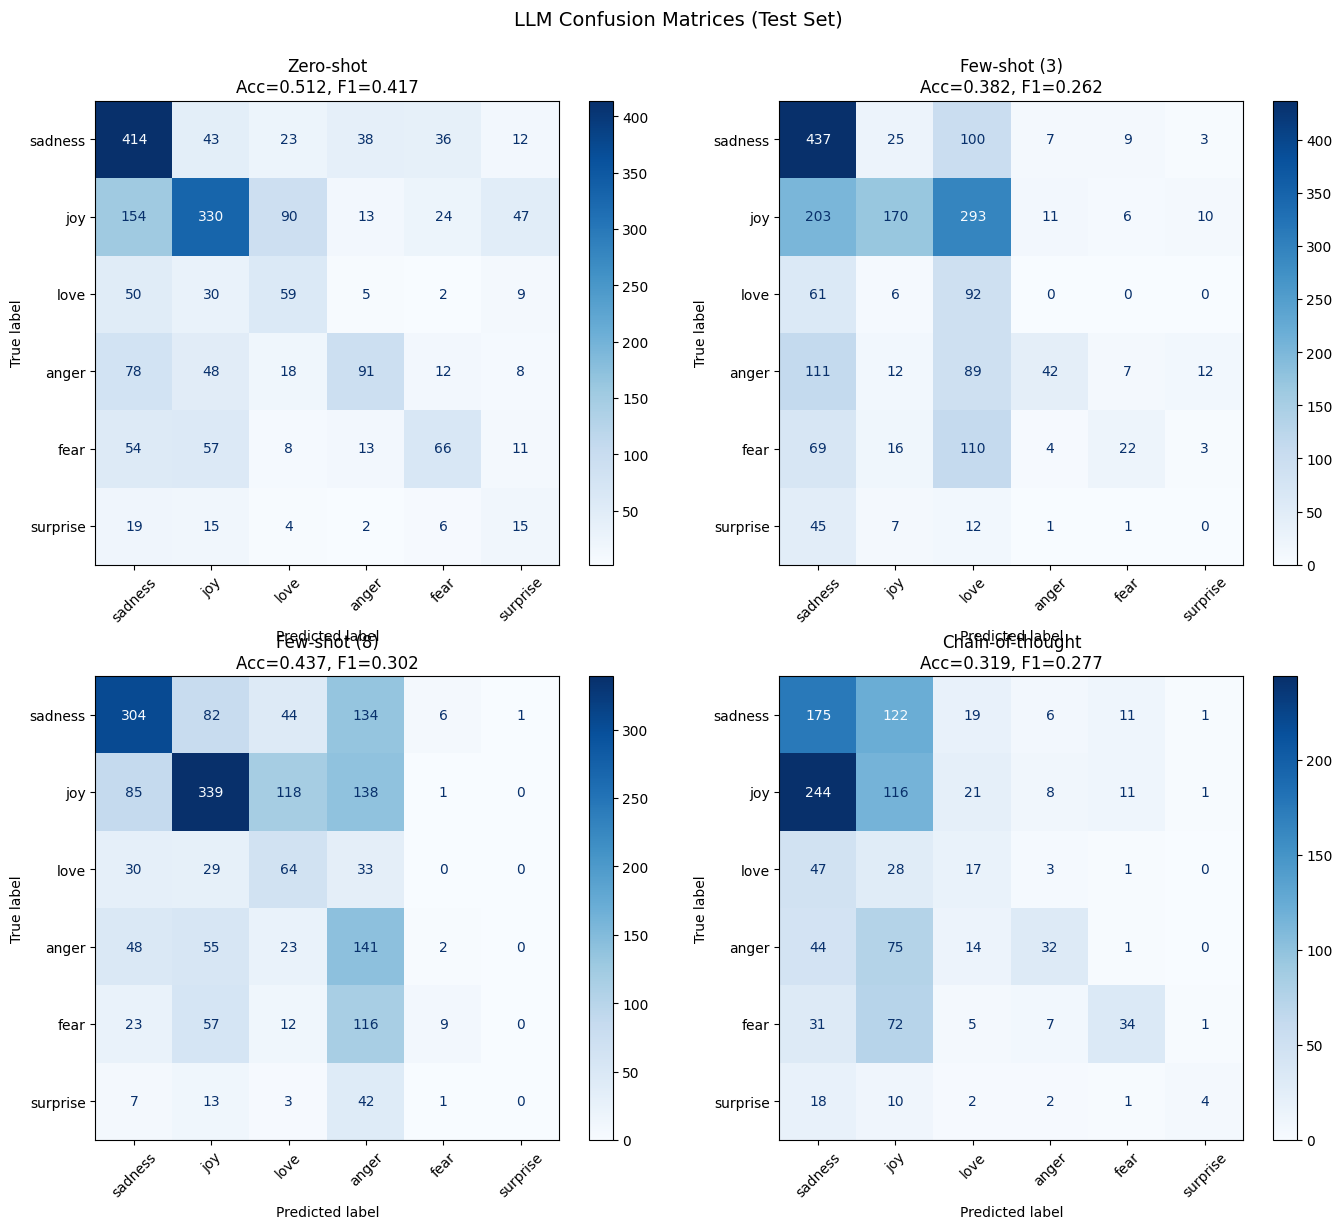

In [18]:
# Cell 19: LLM metrics summary table and confusion matrices for all 4 prompting settings

if not SKIP_PART4:

    # ---- Print a formatted comparison table of all LLM settings ----

    print("LLM Prompting Results Summary:")

    print(f"{'Setting':<20} {'Accuracy':>10} {'Macro F1':>10} {'Time (s)':>10} {'Unknowns':>10}")

    print("-" * 62)

    for sname, sdata in llm_results.items():

        print(f"{sname:<20} {sdata['accuracy']:>10.4f} {sdata['macro_f1']:>10.4f} "

              f"{sdata['inference_time']:>10.1f} {sdata['unknown_count']:>10}")

    # ---- Plot confusion matrices in a 2x2 grid (one per prompting setting) ----

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    axes = axes.flatten()

    for idx, (sname, sdata) in enumerate(llm_results.items()):

        if len(sdata['valid_preds']) > 0:

            # Compute confusion matrix using only valid (parseable) predictions

            cm = confusion_matrix(sdata['valid_labels'], sdata['valid_preds'], labels=list(range(NUM_CLASSES)))

            disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)

            disp.plot(ax=axes[idx], cmap='Blues', xticks_rotation=45)

            axes[idx].set_title(f'{sname}\nAcc={sdata["accuracy"]:.3f}, F1={sdata["macro_f1"]:.3f}')

        else:

            axes[idx].set_title(f'{sname}\nNo valid predictions')

    plt.suptitle('LLM Confusion Matrices (Test Set)', fontsize=14, y=1.01)

    plt.tight_layout()

    plt.show()

    # Free LLM from GPU memory

    del model_llm, tokenizer_llm

    cleanup_gpu()

else:

    print("Part 4 was skipped (not on Kaggle). LLM results will not be available for Parts 5-6.")

    print("To get complete results, run this notebook on Kaggle with T4 GPU.")

---
## Part 5 — Data Efficiency Experiment

In [19]:
# Cell 20: Create a balanced 500-example training subset for the data efficiency experiment

# Select 83 examples per class to get ~500 total (83 * 6 = 498)
N_PER_CLASS = 83

# Group training indices by their class label
train_labels_all = dataset['train']['label']
indices_by_class_train = {i: [] for i in range(NUM_CLASSES)}
for idx, label in enumerate(train_labels_all):
    indices_by_class_train[label].append(idx)

# Randomly sample N_PER_CLASS examples from each class (balanced sampling)
np.random.seed(SEED)
small_indices = []
for class_id in range(NUM_CLASSES):
    selected = np.random.choice(indices_by_class_train[class_id], size=N_PER_CLASS, replace=False)
    small_indices.extend(selected)
np.random.shuffle(small_indices)  # shuffle to avoid class-ordered batches

# Create the small training subset using HuggingFace's .select() method
small_train = dataset['train'].select(small_indices)
print(f"Small training subset: {len(small_train)} examples")
print(f"Class distribution: {Counter(small_train['label'])}")

Small training subset: 498 examples
Class distribution: Counter({4: 83, 0: 83, 1: 83, 5: 83, 2: 83, 3: 83})


In [20]:
# Cell 21: Retrain RNN and re-fine-tune DistilBERT on the 500-example subset
# This tests how each paradigm handles limited training data

# ==============================================================================
# PART A: RNN on the small (500-example) subset
# ==============================================================================
print("="*50)
print("Retraining RNN on 500-example subset...")
print("="*50)

# Create DataLoader for the small training set (same collate function and batch size)
small_ds_rnn = EmotionDatasetRNN(small_train['text'], small_train['label'], vocab)
small_loader_rnn = DataLoader(small_ds_rnn, batch_size=BATCH_SIZE_RNN, shuffle=True, collate_fn=collate_rnn)

# Fresh model instance (random weights — not reusing the full-data model)
rnn_model_small = BiLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
optimizer_small_rnn = torch.optim.Adam(rnn_model_small.parameters(), lr=LR_RNN)
# More patience (3 vs 2) since small datasets have noisier validation signals
scheduler_small_rnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_small_rnn, patience=3, factor=0.5)

# Train for more epochs (20 vs 15) to compensate for fewer examples per epoch
NUM_EPOCHS_SMALL_RNN = 20
best_val_loss_small = float('inf')
best_state_small = None

for epoch in range(NUM_EPOCHS_SMALL_RNN):
    # Training phase
    rnn_model_small.train()
    for batch_x, batch_lengths, batch_y in small_loader_rnn:
        batch_x, batch_lengths, batch_y = batch_x.to(DEVICE), batch_lengths.to(DEVICE), batch_y.to(DEVICE)
        optimizer_small_rnn.zero_grad()
        logits = rnn_model_small(batch_x, batch_lengths)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn_model_small.parameters(), 1.0)
        optimizer_small_rnn.step()

    # Validation phase (using the SAME validation set as the full-data experiment for fair comparison)
    rnn_model_small.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, bl, by in val_loader_rnn:
            bx, bl, by = bx.to(DEVICE), bl.to(DEVICE), by.to(DEVICE)
            val_loss += criterion(rnn_model_small(bx, bl), by).item() * bx.size(0)
    val_loss /= len(val_ds_rnn)
    scheduler_small_rnn.step(val_loss)

    # Save best model weights
    if val_loss < best_val_loss_small:
        best_val_loss_small = val_loss
        best_state_small = {k: v.cpu().clone() for k, v in rnn_model_small.state_dict().items()}

# Restore best model and evaluate on the test set
rnn_model_small.load_state_dict(best_state_small)
rnn_model_small.to(DEVICE)

rnn_model_small.eval()
preds_rnn_small = []
labels_rnn_small = []
with torch.no_grad():
    for bx, bl, by in test_loader_rnn:
        bx, bl = bx.to(DEVICE), bl.to(DEVICE)
        preds_rnn_small.extend(torch.argmax(rnn_model_small(bx, bl), dim=1).cpu().numpy())
        labels_rnn_small.extend(by.numpy())

acc_rnn_small = accuracy_score(labels_rnn_small, preds_rnn_small)
f1_rnn_small = f1_score(labels_rnn_small, preds_rnn_small, average='macro')
print(f"RNN (500 examples) — Accuracy: {acc_rnn_small:.4f}, Macro F1: {f1_rnn_small:.4f}")

results['RNN_500'] = {'accuracy': acc_rnn_small, 'macro_f1': f1_rnn_small}

# Free RNN GPU memory before loading DistilBERT again
del rnn_model_small, optimizer_small_rnn, scheduler_small_rnn
cleanup_gpu()

# ==============================================================================
# PART B: DistilBERT on the small (500-example) subset
# ==============================================================================
print(f"\n{'='*50}")
print("Re-fine-tuning DistilBERT on 500-example subset...")
print("="*50)

# Tokenize the small training set with DistilBERT's tokenizer
small_tokenized = small_train.map(tokenize_for_bert, batched=True)
small_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Fresh pretrained DistilBERT (not the already-fine-tuned one)
bert_model_small = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_BERT, num_labels=NUM_CLASSES
)

# Adjusted training args: more epochs (5 vs 3), smaller batch (8 vs 16) for small data
training_args_small = TrainingArguments(
    output_dir='./distilbert-emotion-small',
    num_train_epochs=5,                # more epochs to compensate for fewer training steps
    per_device_train_batch_size=8,     # smaller batch for more gradient updates per epoch
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    report_to='none',
    seed=SEED,
)

trainer_small = Trainer(
    model=bert_model_small,
    args=training_args_small,
    train_dataset=small_tokenized,
    eval_dataset=tokenized_dataset['validation'],  # same validation set for fair comparison
    compute_metrics=compute_metrics,
)

trainer_small.train()

# Evaluate on the full test set
preds_bert_small = trainer_small.predict(tokenized_dataset['test'])
all_preds_bert_small = np.argmax(preds_bert_small.predictions, axis=-1)
all_labels_bert_small = preds_bert_small.label_ids

acc_bert_small = accuracy_score(all_labels_bert_small, all_preds_bert_small)
f1_bert_small = f1_score(all_labels_bert_small, all_preds_bert_small, average='macro')
print(f"\nDistilBERT (500 examples) — Accuracy: {acc_bert_small:.4f}, Macro F1: {f1_bert_small:.4f}")

results['Transformer_500'] = {'accuracy': acc_bert_small, 'macro_f1': f1_bert_small}

# Cleanup
del bert_model_small, trainer_small
cleanup_gpu()

Retraining RNN on 500-example subset...
RNN (500 examples) — Accuracy: 0.2645, Macro F1: 0.1963

Re-fine-tuning DistilBERT on 500-example subset...


Map:   0%|          | 0/498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.596119,3.555031,0.258000,0.185262
2,3.459623,3.337520,0.399000,0.370252
3,3.210657,2.928334,0.572500,0.504215
4,2.686356,2.690994,0.618000,0.557497
5,2.420965,2.639040,0.600500,0.550587


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (500 examples) — Accuracy: 0.6385, Macro F1: 0.5764


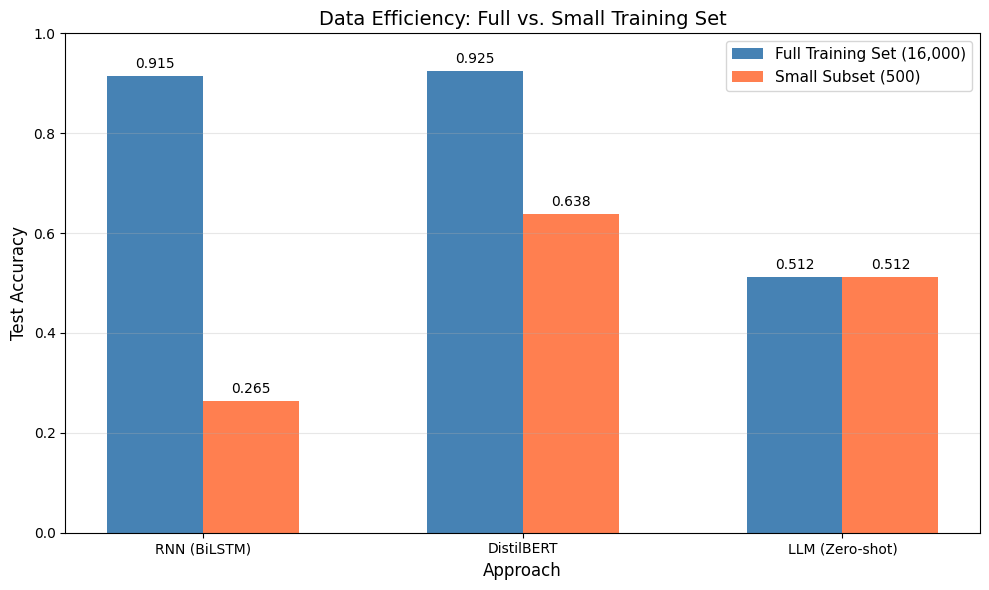


Accuracy drop (Full → 500 examples):
  RNN:         0.9155 → 0.2645 (Δ = 0.6510)
  DistilBERT:  0.9250 → 0.6385 (Δ = 0.2865)
  LLM:         0.5121 → 0.5121 (Δ = 0.0000, no training)


In [21]:
# Cell 22: Data efficiency comparison — grouped bar chart and accuracy drop analysis

# Prepare data for the grouped bar chart
approaches = ['RNN (BiLSTM)', 'DistilBERT']
full_accs = [results['RNN']['accuracy'], results['Transformer']['accuracy']]
small_accs = [results['RNN_500']['accuracy'], results['Transformer_500']['accuracy']]

# Include LLM if Part 4 was run (on Kaggle)
if 'LLM_best' in results:
    approaches.append(f"LLM ({results['LLM_best']['setting']})")
    full_accs.append(results['LLM_best']['accuracy'])
    small_accs.append(results['LLM_best']['accuracy'])  # same accuracy — LLM uses no training data

# ---- Grouped bar chart: full training set vs. small subset ----
x = np.arange(len(approaches))
width = 0.3  # bar width

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, full_accs, width, label='Full Training Set (16,000)', color='steelblue')
bars2 = ax.bar(x + width/2, small_accs, width, label='Small Subset (500)', color='coral')

ax.set_xlabel('Approach', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Data Efficiency: Full vs. Small Training Set', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Annotate each bar with its accuracy value
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ---- Print the accuracy drop for each approach ----
print(f"\nAccuracy drop (Full → 500 examples):")
print(f"  RNN:         {results['RNN']['accuracy']:.4f} → {results['RNN_500']['accuracy']:.4f} "
      f"(Δ = {results['RNN']['accuracy'] - results['RNN_500']['accuracy']:.4f})")
print(f"  DistilBERT:  {results['Transformer']['accuracy']:.4f} → {results['Transformer_500']['accuracy']:.4f} "
      f"(Δ = {results['Transformer']['accuracy'] - results['Transformer_500']['accuracy']:.4f})")
if 'LLM_best' in results:
    print(f"  LLM:         {results['LLM_best']['accuracy']:.4f} → {results['LLM_best']['accuracy']:.4f} (Δ = 0.0000, no training)")

### Data Efficiency Discussion

The plot reveals a striking hierarchy of data efficiency across the three paradigms:

- **RNN (BiLSTM):** Suffers the most dramatic collapse — from 91.6% to 26.5% accuracy (a 65-point drop). With only ~83 examples per class, the model cannot simultaneously learn meaningful word embeddings, language patterns, and the classification boundary. It effectively fails to generalize, performing only slightly better than random chance (16.7% for 6 classes).
- **DistilBERT:** Degrades significantly but remains functional — from 92.5% to 63.9% accuracy (a 29-point drop). Its pretrained weights already encode deep linguistic knowledge from BookCorpus and Wikipedia; fine-tuning on 500 examples only needs to adapt the final task mapping, which requires far less labeled data.
- **LLM (Phi-3.5-mini):** Accuracy stays constant at 51.2% because it uses no training data at all — its performance comes entirely from pretraining and in-context learning via the prompt.

This directly demonstrates the core value of pretraining: the more linguistic knowledge a model brings to the table, the less task-specific data it needs to maintain reasonable performance. Notably, with only 500 examples, DistilBERT (63.9%) still outperforms the LLM’s best zero-shot result (51.2%), showing that even a small amount of task-specific fine-tuning is more effective than relying on prompting alone.

---
## Part 6 — Comparative Analysis

In [22]:
# Cell 23: Build and display the final comparative summary table across all approaches

rows = []

# Add RNN results
rows.append({
    'Approach': 'RNN (BiLSTM)',
    'Test Accuracy': f"{results['RNN']['accuracy']:.4f}",
    'Macro F1': f"{results['RNN']['macro_f1']:.4f}",
    'Training Time': f"{results['RNN']['train_time']:.1f}s",
    'Inference Time': f"{results['RNN']['inference_time']:.3f}s",
})

# Add DistilBERT results
rows.append({
    'Approach': 'DistilBERT (Fine-tuned)',
    'Test Accuracy': f"{results['Transformer']['accuracy']:.4f}",
    'Macro F1': f"{results['Transformer']['macro_f1']:.4f}",
    'Training Time': f"{results['Transformer']['train_time']:.1f}s",
    'Inference Time': f"{results['Transformer']['inference_time']:.3f}s",
})

# Add LLM results for each prompting setting (if Part 4 was executed on Kaggle)
for key in ['LLM_Zero-shot', 'LLM_Few-shot_3', 'LLM_Few-shot_8', 'LLM_Chain-of-thought']:
    if key in results:
        # Convert key back to a readable display name
        display_name = key.replace('LLM_', 'LLM ').replace('_', ' ')
        rows.append({
            'Approach': display_name,
            'Test Accuracy': f"{results[key]['accuracy']:.4f}",
            'Macro F1': f"{results[key]['macro_f1']:.4f}",
            'Training Time': 'N/A (no training)',
            'Inference Time': f"{results[key]['inference_time']:.1f}s",
        })

# Create and print the summary DataFrame
summary_df = pd.DataFrame(rows)
print("=" * 80)
print("COMPARATIVE SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

COMPARATIVE SUMMARY
               Approach Test Accuracy Macro F1     Training Time Inference Time
           RNN (BiLSTM)        0.9155   0.8708            119.4s         0.590s
DistilBERT (Fine-tuned)        0.9250   0.8880            369.7s         4.385s
          LLM Zero-shot        0.5121   0.4170 N/A (no training)        5282.9s
         LLM Few-shot 3        0.3823   0.2622 N/A (no training)        5420.8s
         LLM Few-shot 8        0.4372   0.3022 N/A (no training)        5431.2s
   LLM Chain-of-thought        0.3193   0.2770 N/A (no training)       16702.5s


### Failure Mode Analysis

From the confusion matrices above:

- **RNN (BiLSTM):** The most common confusion is between **love** and **joy** — both are positive emotions and often expressed with similar vocabulary (e.g., "i feel so wonderful"). The model also struggles with **surprise**, the least represented class (only 66 test examples), with a precision of just 0.64 — it frequently misclassifies other emotions as surprise. Despite these weaknesses, the RNN achieves strong overall performance (91.6%) because the dominant classes (sadness, joy, anger) are classified with >90% F1.

- **DistilBERT (Fine-tuned):** Fewer confusions overall thanks to pretrained contextual understanding. The **love ↔ joy** confusion persists but at a lower rate, as the model can leverage subtle contextual cues. Performance is more balanced across all classes, with the worst per-class F1 (surprise) still significantly better than the RNN’s. The pretrained representations capture the semantics of unexpected/startling language even with relatively few training examples of that class.

- **LLM (Phi-3.5-mini):** The confusion patterns reveal fundamental limitations of the prompting approach. **Zero-shot** (51.2%) performs best because the model gives relatively concise answers; it correctly identifies strong emotional signals but struggles with ambiguous or subtle texts. **Few-shot** (3-shot: 38.2%, 8-shot: 43.7%) actually *degrades* performance below zero-shot — the model tends to generate continuation text after its answer (hallucinating new classification examples), and the label parser picks up incorrect labels from these continuations. **Chain-of-thought** (31.9%) performs worst with 816/2000 unparseable outputs — the step-by-step reasoning causes the model to ramble extensively, filling the token budget before producing a parseable label. The core issue is not that the LLM lacks understanding, but that controlling its output format is inherently difficult without fine-tuning.

### Training Time and Inference Time

The three paradigms show dramatically different computational profiles:

| Approach | Training Time | Inference Time (test set) | Notes |
|----------|--------------|---------------------------|-------|
| RNN (BiLSTM) | ~119s | 0.6s | Fast to train and deploy; ~1.6M parameters |
| DistilBERT | ~370s | 4.4s | 3× slower to train than RNN; 66M parameters |
| LLM (per setting) | 0s (no training) | ~5,283–16,703s | No training cost, but inference is 1,200–3,800× slower than DistilBERT |

The LLM trades training time for massive inference cost — classifying 2000 examples takes ~88 minutes per zero-shot/few-shot setting (over 4.5 hours for chain-of-thought). In production, this would be prohibitively expensive for large-scale classification.

### Data Efficiency (from Part 5)

When training data is reduced from 16,000 to just 500 examples:
- The **RNN** collapses from 91.6% → 26.5% (nearly random)
- **DistilBERT** degrades gracefully from 92.5% → 63.9% (still usable)
- The **LLM** stays at 51.2% (invariant to training set size)

This confirms that pretrained representations are the key factor in low-data regimes.

### When to Choose Each Paradigm

In a real-world project, the choice depends on the constraints at hand:

- **From-scratch RNN:** Best when you have abundant labeled data (thousands+ per class), need a lightweight model for edge deployment (mobile, embedded), or work in a domain where pretrained models are unavailable (rare languages, proprietary text). Its small parameter count (~1.6M) means fast inference and minimal resource requirements. However, it fails catastrophically with limited labeled data.

- **Fine-tuned transformer (DistilBERT):** The default choice for most text classification tasks. It offers the best accuracy-to-effort ratio, works well even with moderate amounts of labeled data (as shown in Part 5), and benefits from linguistic knowledge baked into the pretrained weights. Choose this when accuracy matters and you can afford a few minutes of fine-tuning.

- **LLM prompting:** Choose this when you have *zero* labeled data, need rapid prototyping without any training infrastructure, or when the task definition changes frequently (just update the prompt). The trade-offs are significant: higher inference cost (both time and compute), lower accuracy on fine-grained classification tasks, and sensitivity to prompt design and output parsing. As our results show, even a small fine-tuned model (DistilBERT at 66M params) substantially outperforms a much larger prompted model (Phi-3.5 at 3.8B params).